In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from icdmappings import Mapper


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)


In [2]:
val_df   = pd.read_csv("data/val.csv")
target = "TriageGrade"
mapper = Mapper()

val_df['Block'] =mapper.map(val_df['ChiefComplaint'], source='icd10', target='block')

y_test = val_df[target]

CLASS_PRIORITY = 4
TARGET_RECALL = 0.90


In [3]:
models_to_test = [
    "models/models/baseline_block.joblib",
    "models/models/baseline_peso_block.joblib",
    #"models/models/gb_varias.joblib",
    "models/models/rf_block.joblib",
    "models/models/rf_peso_block.joblib",
    "models/models/rf_peso_varias.joblib",
    "models/models/rf_varias.joblib",
]

In [4]:
def precision_at_target_recall(y_true, probas, target_recall):
    precision, recall, thresholds = precision_recall_curve(y_true, probas)

    valid = np.where(recall >= target_recall)[0]
    if len(valid) == 0:
        return 0.0, 1.0

    best = valid[np.argmax(precision[valid])]
    threshold = thresholds[best] if best < len(thresholds) else 1.0

    return float(precision[best]), float(threshold)



In [5]:
def plot_confusion(y_true, preds, ax, title):
    cm = confusion_matrix(y_true, preds, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")



In [6]:
def plot_pr(y_true, probas, ax, title):
    classes = np.unique(y_true)
    idx = list(classes).index(CLASS_PRIORITY)

    y_bin = (y_true == CLASS_PRIORITY).astype(int)
    precision, recall, _ = precision_recall_curve(y_bin, probas[:, idx])

    ax.plot(recall, precision)
    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True)



In [7]:
def plot_threshold(y_true, probas, ax, title):
    classes = np.unique(y_true)
    idx = list(classes).index(CLASS_PRIORITY)

    y_bin = (y_true == CLASS_PRIORITY).astype(int)
    probs = probas[:, idx]

    thresholds = np.linspace(0, 1, 100)
    recalls, precisions = [], []

    for th in thresholds:
        preds = (probs >= th).astype(int)
        recalls.append(recall_score(y_bin, preds, zero_division=0))
        precisions.append(precision_score(y_bin, preds, zero_division=0))

    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, precisions, label="Precision")
    ax.axvline(0.5, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.legend()
    ax.grid(True)



In [8]:
def evaluate_model(path, X_df, y_true):
    data = joblib.load(path)
    model = data["model"]
    features = data["features"]
    name = path.split("/")[-1]

    X = X_df[features]

    preds = model.predict(X)
    probas = model.predict_proba(X)

    report = classification_report(y_true, preds, output_dict=True, zero_division=0)

    accuracy = accuracy_score(y_true, preds)
    f1_w = f1_score(y_true, preds, average="weighted", zero_division=0)

    classes = np.unique(y_true)
    idx = list(classes).index(CLASS_PRIORITY)
    y_bin = (y_true == CLASS_PRIORITY).astype(int)
    probas_c4 = probas[:, idx]

    ap = average_precision_score(y_bin, probas_c4)
    prec_target, th_target = precision_at_target_recall(
        y_bin, probas_c4, TARGET_RECALL
    )

    metrics = {
        "model": name,
        "accuracy": accuracy,
        "f1_weighted": f1_w,
        "recall_class_4": report[str(CLASS_PRIORITY)]["recall"],
        "average_precision_class_4": ap,
        f"precision_at_{TARGET_RECALL}_recall": prec_target,
        "threshold_for_target_recall": th_target
    }

    recall_rows = []
    f1_rows = []

    for cls in report.keys():
        if cls.isdigit():
            recall_rows.append({
                "model": name,
                "class": int(cls),
                "recall": report[cls]["recall"]
            })
            f1_rows.append({
                "model": name,
                "class": int(cls),
                "f1_score": report[cls]["f1-score"]
            })

    return metrics, preds, probas, recall_rows, f1_rows


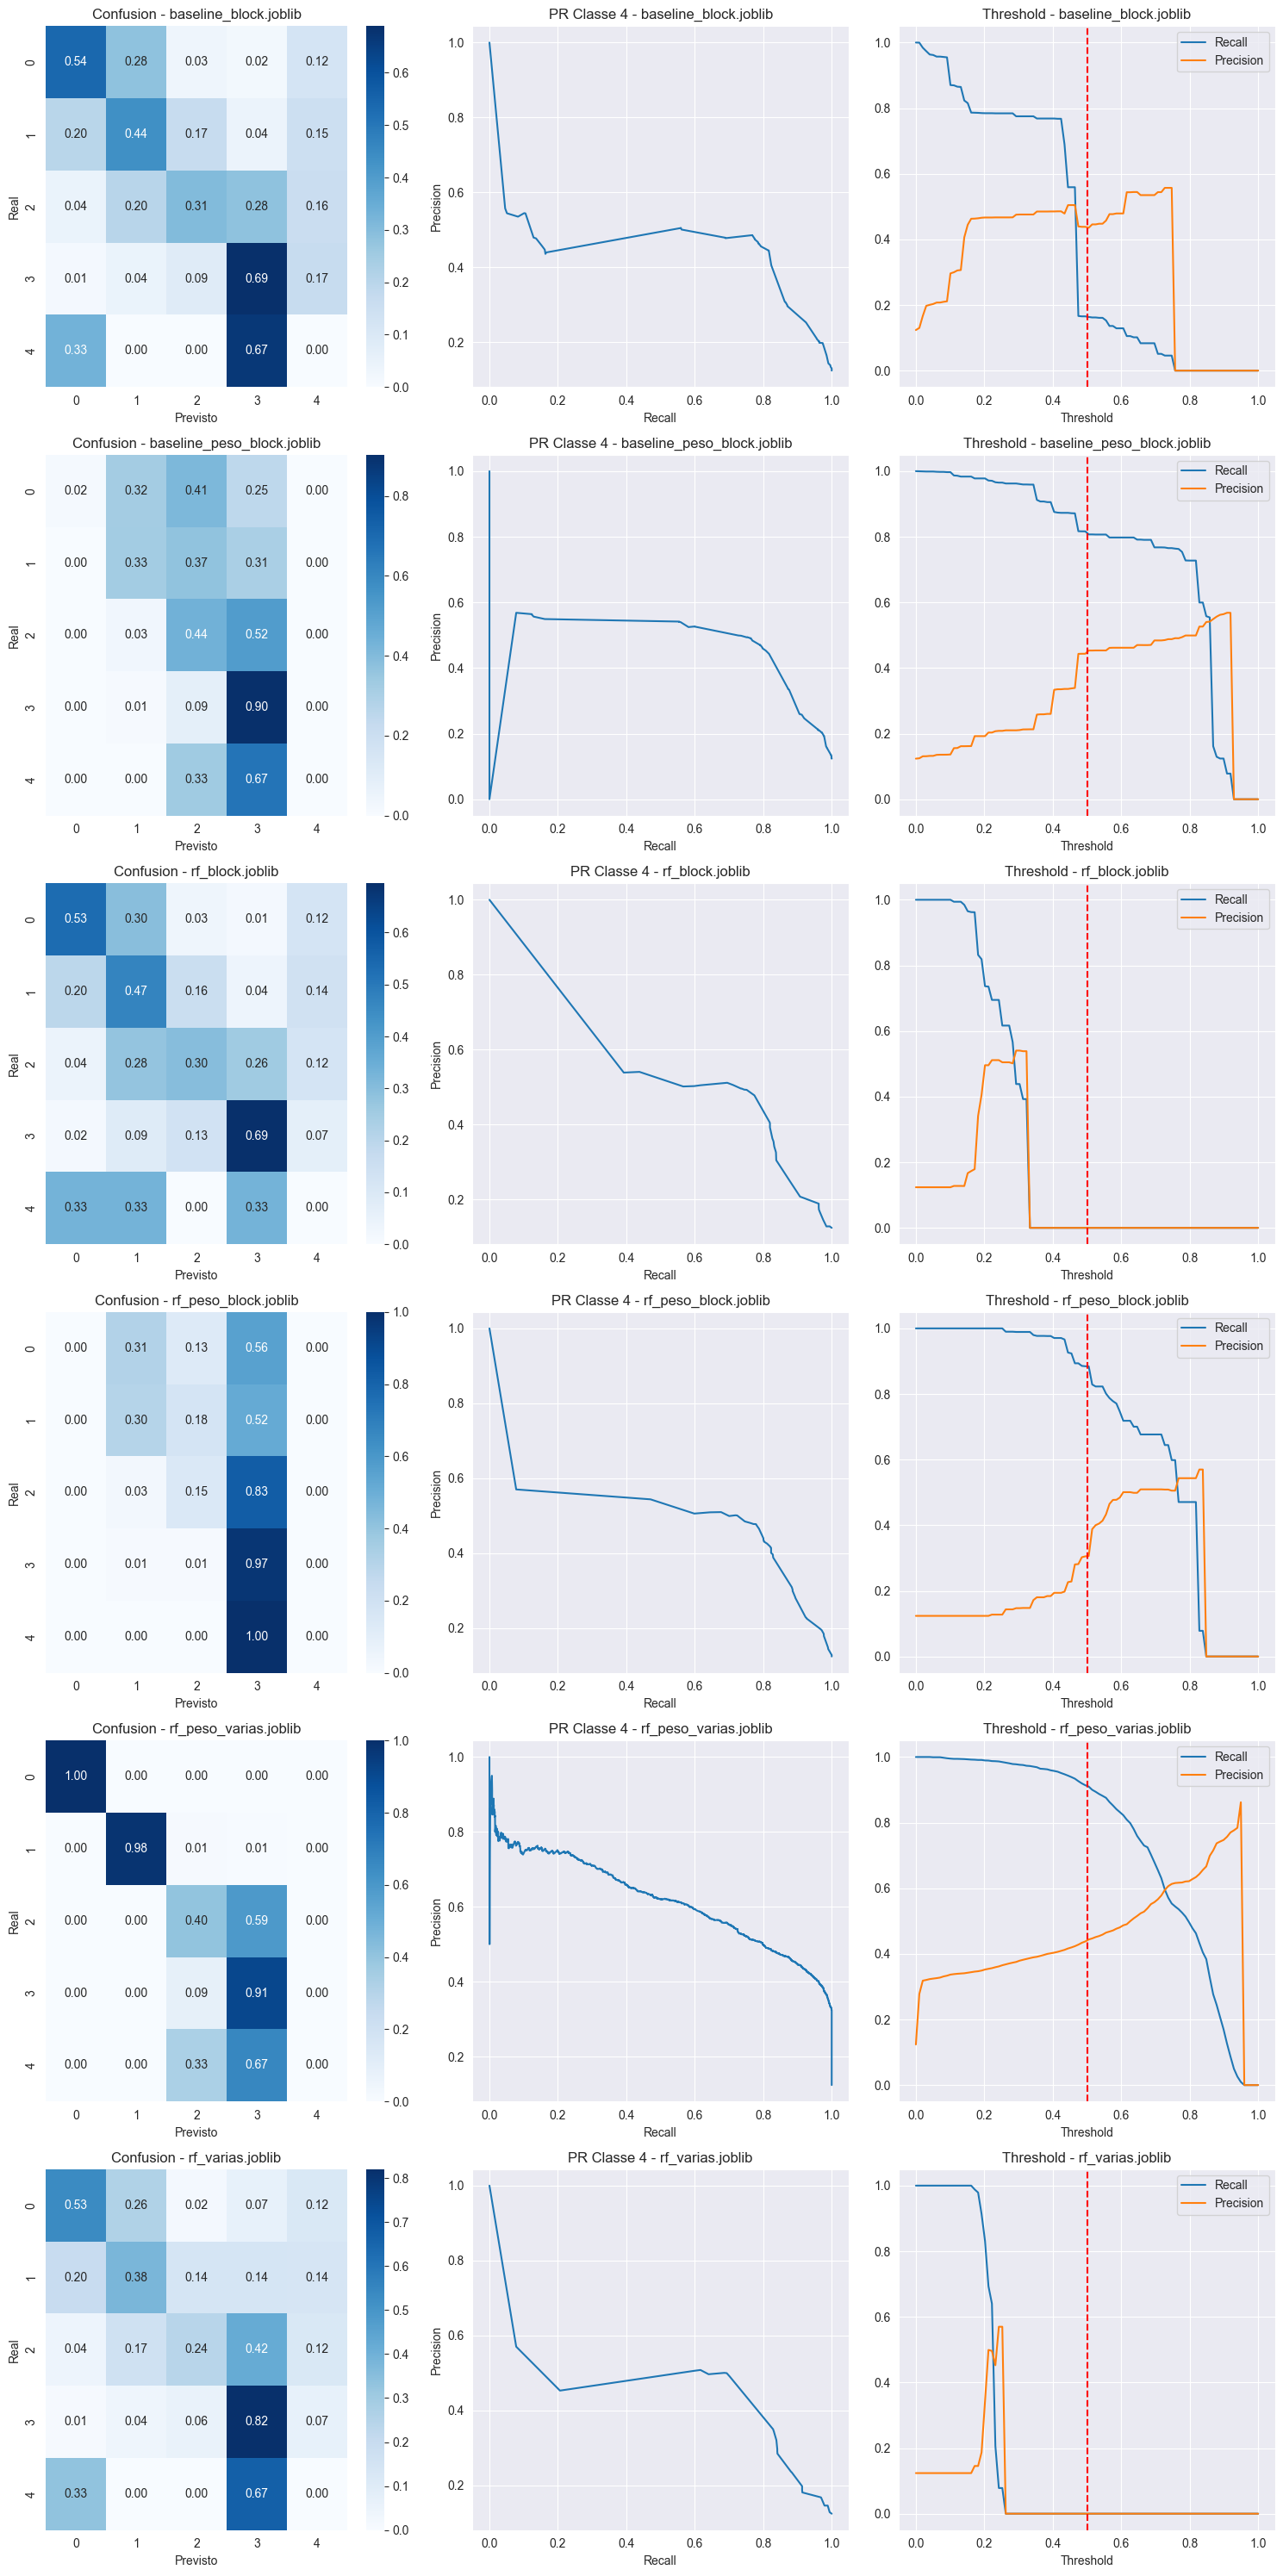

In [9]:
results = []
recall_all = []
f1_all = []

num_models = len(models_to_test)
fig, axes = plt.subplots(num_models, 3, figsize=(15, 5 * num_models))

for i, path in enumerate(models_to_test):
    metrics, preds, probas, recall_rows, f1_rows = evaluate_model(path, val_df, y_test)

    results.append(metrics)
    recall_all.extend(recall_rows)
    f1_all.extend(f1_rows)


    name = metrics["model"]

    plot_confusion(y_test, preds, axes[i, 0], f"Confusion - {name}")
    plot_pr(y_test, probas, axes[i, 1], f"PR Classe 4 - {name}")
    plot_threshold(y_test, probas, axes[i, 2], f"Threshold - {name}")

plt.tight_layout()
plt.show()


In [10]:
df_final = pd.DataFrame(results)
df_recalls_all = pd.DataFrame(recall_all)
df_f1_all = pd.DataFrame(f1_all)

df_final = df_final.sort_values(
    by=["recall_class_4", f"precision_at_{TARGET_RECALL}_recall"],
    ascending=False
)

print(df_final)
df_final.to_csv("model_comparison.csv", index=False)



                        model  accuracy  f1_weighted  recall_class_4  \
3        rf_peso_block.joblib  0.326790     0.334108        0.974060   
4       rf_peso_varias.joblib  0.836303     0.835293        0.913534   
1  baseline_peso_block.joblib  0.402196     0.403243        0.903008   
5            rf_varias.joblib  0.412057     0.443418        0.819925   
2             rf_block.joblib  0.461599     0.501130        0.694737   
0       baseline_block.joblib  0.443504     0.490572        0.689098   

   average_precision_class_4  precision_at_0.9_recall  \
3                   0.474237                 0.228537   
4                   0.617778                 0.447079   
1                   0.480445                 0.260123   
5                   0.430185                 0.197144   
2                   0.460810                 0.207139   
0                   0.451884                 0.252411   

   threshold_for_target_recall  
3                     0.457466  
4                     0.51492

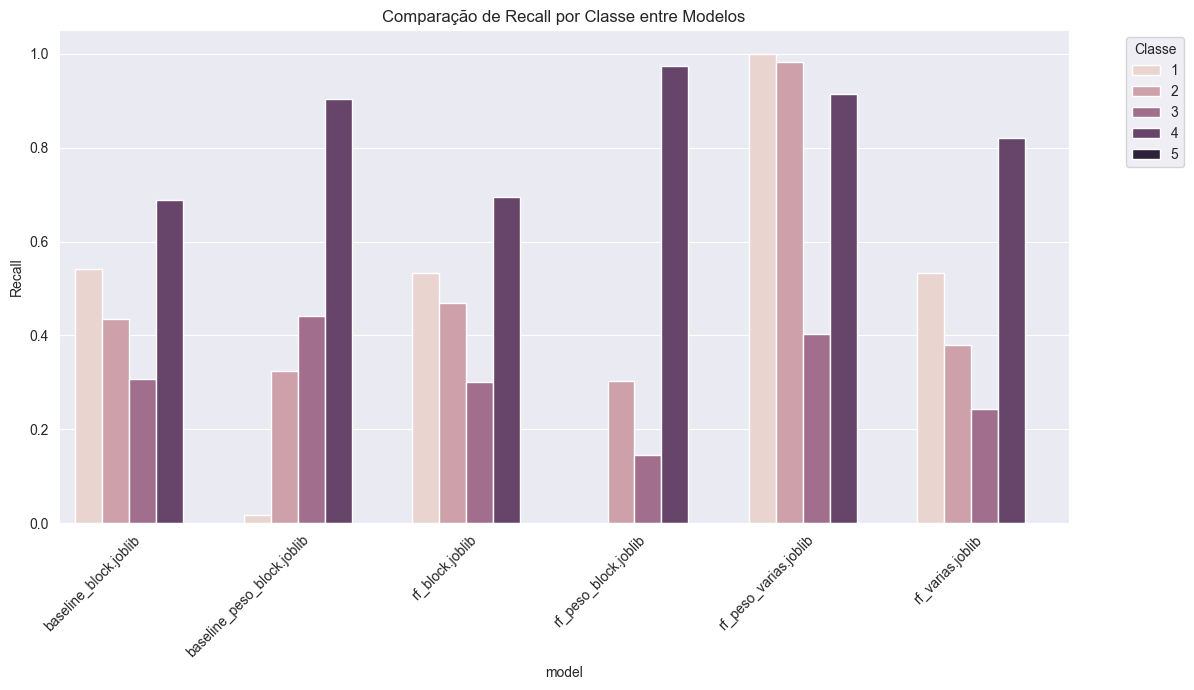

In [11]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df_recalls_all, x='model', y='recall', hue='class')

plt.title("Comparação de Recall por Classe entre Modelos")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Recall")
plt.legend(title="Classe", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


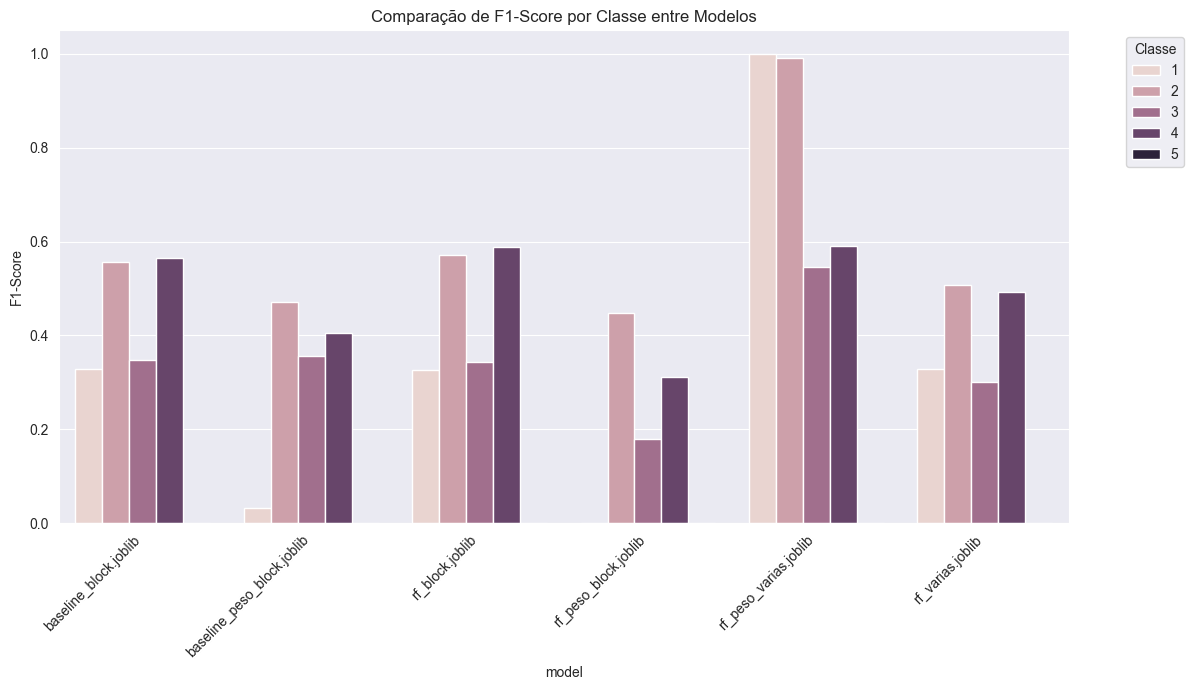

In [12]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df_f1_all, x='model', y='f1_score', hue='class')

plt.title("Comparação de F1-Score por Classe entre Modelos")
plt.xticks(rotation=45, ha='right')
plt.ylabel("F1-Score")
plt.legend(title="Classe", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
